In [2]:
import pandas as pd
df=pd.read_csv("/Users/udayms/NEW/SartUp_Funding/startup_funding_dataset (1).csv")
df.head()

,Startup Name,Industry,Country,Funding Stage,Amount Raised (USD),Funding Date,Number of Employees
0,"Williamson, Greer and Clark",SaaS,Australia,Seed,304706.0,2016-07-03,386
1,"Bradford, Green and Miranda",Finance,India,IPO,641212096.0,2025-08-10,474
2,Kelly LLC,AI,UK,Series A,4149256.0,2024-11-13,220
3,Riggs-Wells,Health,France,IPO,940259054.0,2018-10-03,14
4,"Walters, Edwards and Welch",E-commerce,France,Seed,419487.0,2021-12-27,137


In [3]:
df.columns

Index(['Startup Name', 'Industry', 'Country', 'Funding Stage',
       'Amount Raised (USD)', 'Funding Date', 'Number of Employees'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Startup Name         2000 non-null   object 
 1   Industry             2000 non-null   object 
 2   Country              2000 non-null   object 
 3   Funding Stage        2000 non-null   object 
 4   Amount Raised (USD)  2000 non-null   float64
 5   Funding Date         2000 non-null   object 
 6   Number of Employees  2000 non-null   int64  
dtypes: float64(1), int64(1), object(5)
memory usage: 109.5+ KB


In [5]:
df["Funding Date"]=pd.to_datetime(df["Funding Date"])
df["Year"]=df["Funding Date"].dt.year

In [6]:
df["Year"].head()

0    2016
1    2025
2    2024
3    2018
4    2021
Name: Year, dtype: int32

In [7]:
yearly_funding=df.groupby("Year")["Amount Raised (USD)"].sum()
yearly_funding

Year
2016    3.100964e+10
2017    2.481775e+10
2018    3.383126e+10
2019    3.525316e+10
2020    2.910582e+10
2021    2.696150e+10
2022    2.795999e+10
2023    3.292154e+10
2024    2.504352e+10
2025    3.144870e+10
2026    8.634345e+07
Name: Amount Raised (USD), dtype: float64

In [8]:
years=yearly_funding.index.tolist()
funding=yearly_funding.values.tolist()
years,funding

([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026],
 [31009638786.0,
  24817746954.0,
  33831255088.0,
  35253160994.0,
  29105818273.0,
  26961501630.0,
  27959990485.0,
  32921538806.0,
  25043521611.0,
  31448704294.0,
  86343446.0])

In [9]:
yearly_funding=yearly_funding.drop(2026)
yearly_funding

Year
2016    3.100964e+10
2017    2.481775e+10
2018    3.383126e+10
2019    3.525316e+10
2020    2.910582e+10
2021    2.696150e+10
2022    2.795999e+10
2023    3.292154e+10
2024    2.504352e+10
2025    3.144870e+10
Name: Amount Raised (USD), dtype: float64

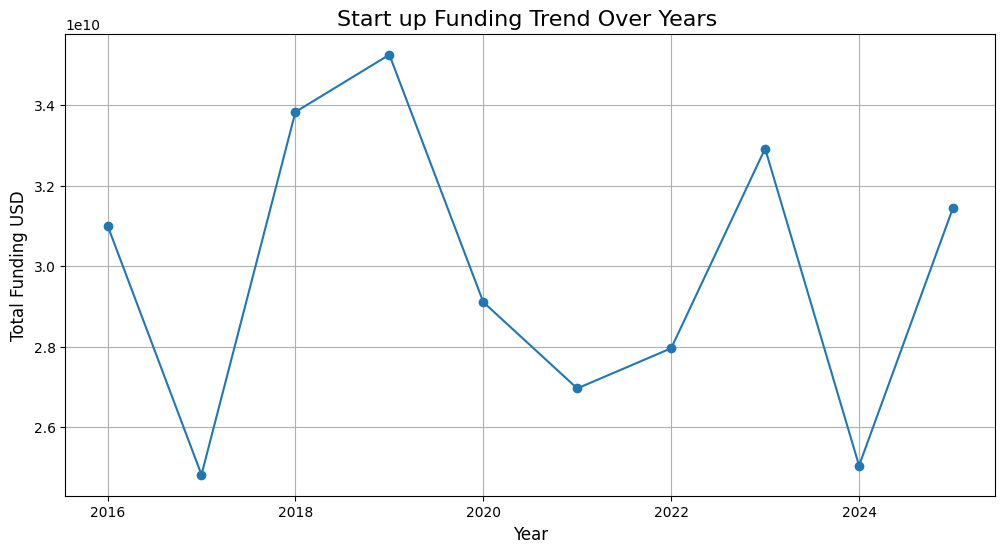

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(yearly_funding.index,yearly_funding.values,marker='o')
plt.title("Start up Funding Trend Over Years ",fontsize=16)
plt.xlabel("Year",fontsize=12)
plt.ylabel("Total Funding USD",fontsize=12)
plt.grid(True)
plt.show()


In [11]:
sector_funding=df.groupby("Industry")["Amount Raised (USD)"].sum()
sector_funding=sector_funding.sort_values(ascending=False)
sector_funding.head(10)

Industry
AI            4.370760e+10
Education     4.000036e+10
Tech          3.960517e+10
Finance       3.827173e+10
Health        3.622630e+10
E-commerce    3.369096e+10
SaaS          3.368749e+10
Gaming        3.324961e+10
Name: Amount Raised (USD), dtype: float64

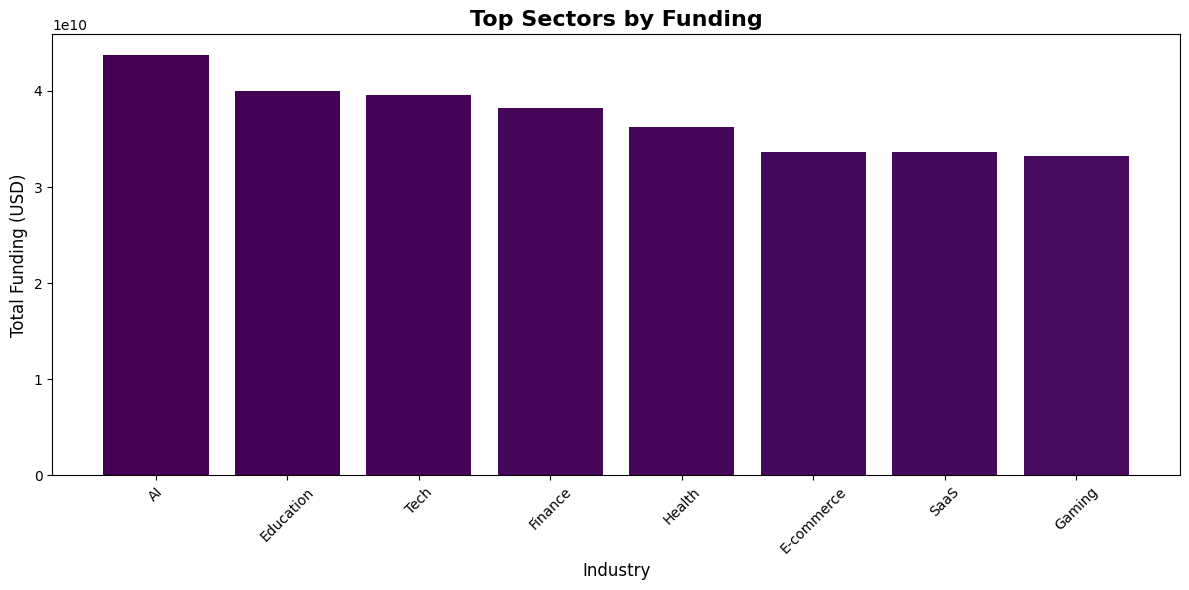

In [15]:
import matplotlib.pyplot as plt
colors=plt.cm.viridis(range(len(sector_funding)))
plt.figure(figsize=(12,6))

plt.bar(sector_funding.index, sector_funding.values,color=colors)

plt.title("Top Sectors by Funding", fontsize=16,fontweight='bold')
plt.xlabel("Industry", fontsize=12)
plt.ylabel("Total Funding (USD)", fontsize=12)

plt.xticks(rotation=45)  # rotate labels for better visibility
plt.tight_layout()
plt.show()

In [19]:
country_funding = df.groupby("Country")["Amount Raised (USD)"].sum()
country_funding = country_funding.sort_values(ascending=False)

country_funding.head()

Country
Canada         4.191562e+10
Netherlands    3.950844e+10
France         3.930798e+10
Germany        3.755725e+10
USA            3.690023e+10
Name: Amount Raised (USD), dtype: float64

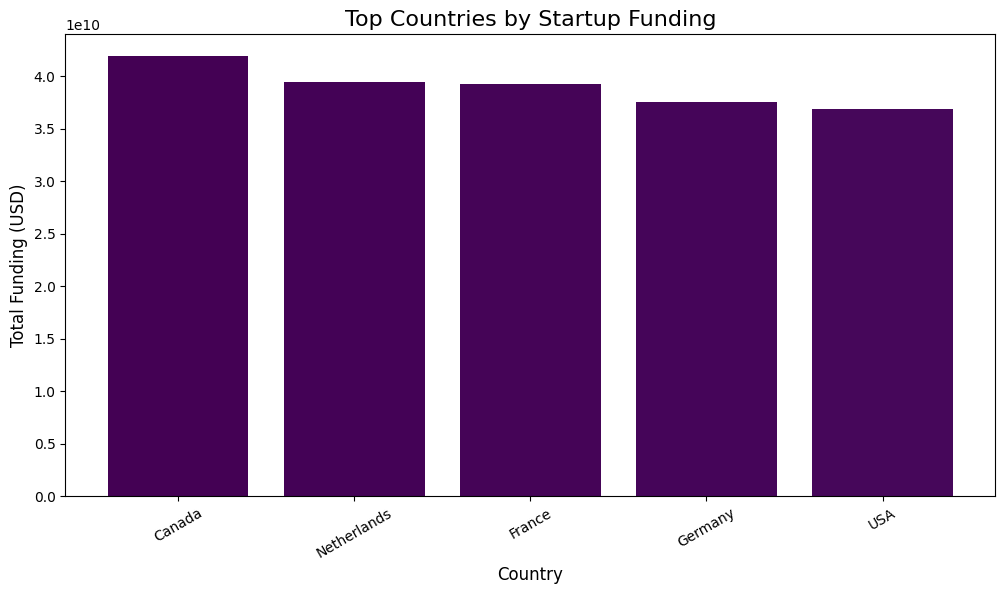

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(country_funding.head().index, country_funding.head().values,color=colors)

plt.title("Top Countries by Startup Funding", fontsize=16)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Total Funding (USD)", fontsize=12)

plt.xticks(rotation=30)



plt.show()

In [23]:
top_sectors = sector_funding.head(5)
top_sectors

Industry
AI           4.370760e+10
Education    4.000036e+10
Tech         3.960517e+10
Finance      3.827173e+10
Health       3.622630e+10
Name: Amount Raised (USD), dtype: float64

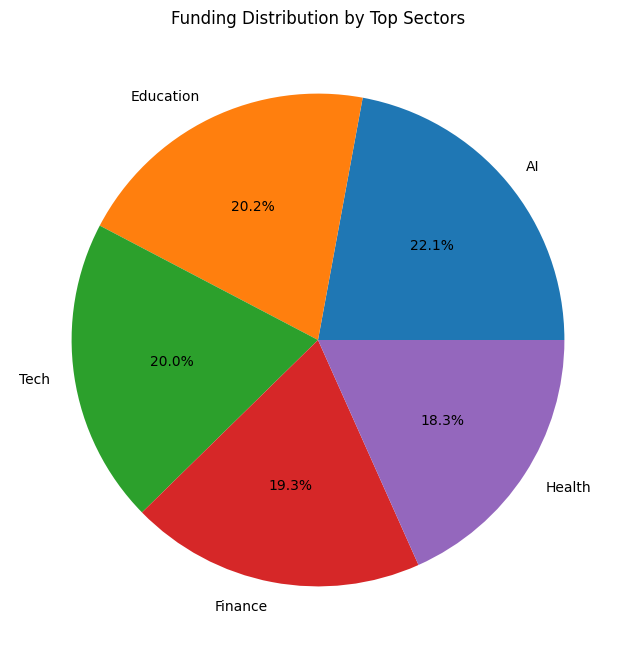

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.pie(top_sectors.values, labels=top_sectors.index, autopct='%1.1f%%')

plt.title("Funding Distribution by Top Sectors")

plt.show()

In [25]:
stage_funding = df.groupby("Funding Stage")["Amount Raised (USD)"].sum()
stage_funding = stage_funding.sort_values(ascending=False)

stage_funding

Funding Stage
IPO         2.302506e+11
Series C    5.368546e+10
Series B    1.230856e+10
Series A    2.093431e+09
Seed        1.011328e+08
Name: Amount Raised (USD), dtype: float64

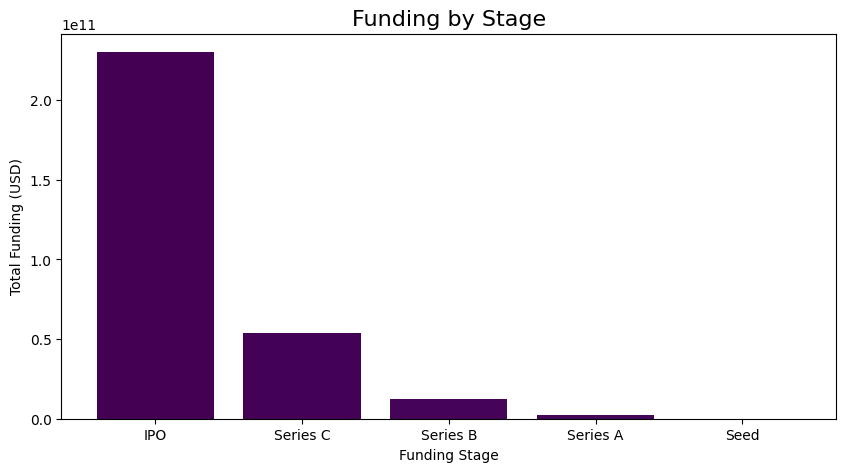

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(stage_funding.index, stage_funding.values,color=colors)

plt.title("Funding by Stage", fontsize=16)
plt.xlabel("Funding Stage")
plt.ylabel("Total Funding (USD)")

plt.show()

In [28]:
df.to_csv("cleaned_data.csv", index=False)